# 文档视觉问答（Doc VQA）Cookbook

本 Cookbook 演示如何调用多模态文档解析模型，完成文档视觉问答（Doc VQA）任务。

## 核心能力

- **文档图像 + 问题 → 精准答案**：基于文档页面图片和用户问题，提取并返回准确答案
- **Thinking 模式**：模型先进行版面分析（识别文本块、表格、图片等区域）定位相关内容，再输出最终答案
- **非 Thinking 模式**：直接根据文档图像和问题输出答案，不包含版面分析过程

## Doc VQA 任务说明

Doc VQA（Document Visual Question Answering）是一种多模态理解任务，要求模型从文档图像中理解并回答问题。

## 两种模式对比

| 特性 | Thinking 模式 | 非 Thinking 模式 |
|------|--------------|------------------|
| 触发方式 | prompt 末尾加 `<think>` | prompt 末尾不加 `<think>` |
| 输出结构 | `<think>...</think>` + 答案 | 直接输出答案 |
| 版面分析 | 有（bbox/label/brief） | 无 |
| 适用场景 | 表格、图表、复杂排版中的信息提取 | 简单文本页面的快速问答 |
| 推理速度 | 较慢 | 较快 |

## 1. 环境准备

In [66]:
import requests
import json
import base64
import re
import os
from PIL import Image, ImageDraw, ImageFont
from typing import List, Dict
from IPython.display import display, Markdown

## 2. 配置参数

图片尺寸: 696 x 916


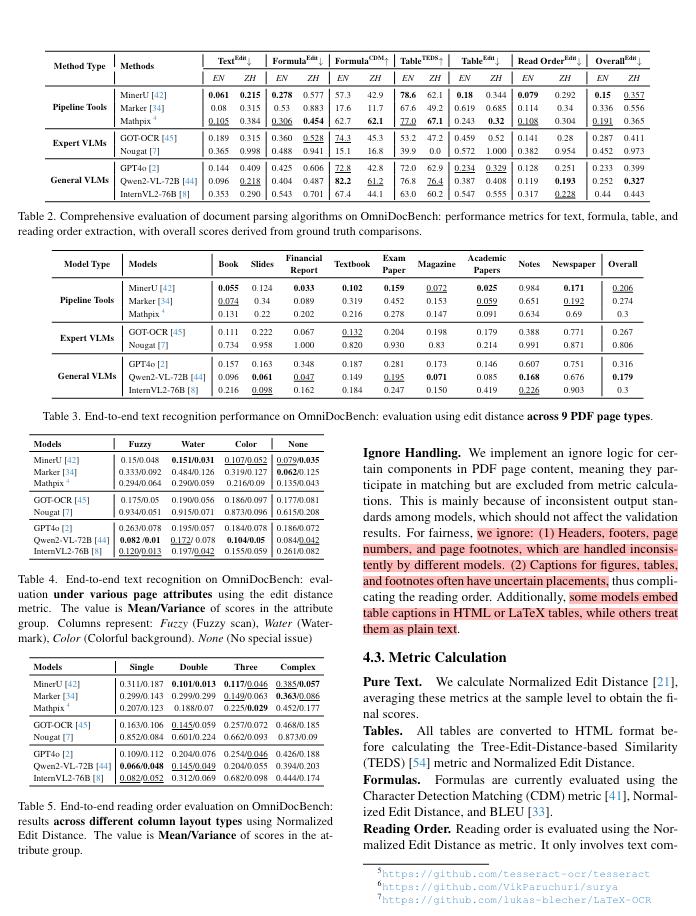

In [ ]:
# vLLM 服务地址
VLLM_URL = ""
API_KEY = ''
MODEL_NAME = ""
INPUT_IMAGE_PATH = "../images/layout_as_thought_for_doc_vqa.png"

# 展示输入图片
input_img = Image.open(INPUT_IMAGE_PATH)
print(f"图片尺寸: {input_img.size[0]} x {input_img.size[1]}")
display(input_img)

## 3. 工具函数

In [68]:
def image_to_base64(image_path: str) -> str:
    """将图片转换为 base64 编码"""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def call_model_vqa(image_path: str, question: str, enable_thinking: bool = True) -> str:
    """调用模型进行文档视觉问答
    
    image_path: 文档图像路径
    question: 用户问题
    enable_thinking: 是否在 user prompt 结尾添加 <think> 触发思考模式
    """
    user_prompt = question
    if enable_thinking:
        user_prompt = user_prompt + '<think>'
    
    image_base64 = image_to_base64(image_path)
    
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{image_base64}"}},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ],
        "max_tokens": 8192,
        "temperature": 0.0,
        "skip_special_tokens": False,
        "max_patch_num": 12
    }
    
    resp = requests.post(VLLM_URL, headers={"Content-Type": "application/json", "Authorization": "Bearer " + API_KEY},
                          data=json.dumps(payload), timeout=120)
    return resp.json()["choices"][0]["message"]["content"]


def extract_answer(response_text: str) -> str:
    """提取最终答案（去除 thinking 部分）"""
    if "</think>" in response_text:
        return response_text.split("</think>", 1)[1].strip()
    return response_text.strip()


def extract_thinking(response_text: str) -> str:
    """提取 Thinking 内容"""
    match = re.search(r'<think>(.*?)</think>', response_text, re.DOTALL)
    return match.group(1).strip() if match else ""


def parse_bbox_from_response(response_text: str) -> List[Dict]:
    """从 Thinking 内容中解析 bbox、label、brief 信息"""
    results = []
    coord_pattern = r'(?:<COORD_(\d+)>|(\d+))'
    
    for open_br, close_br in [(r'\[', r'\]'), (r'\[\[', r'\]'), (r'\[\[', r'\]\]')]:
        pattern = (
            r'<box>' + open_br + coord_pattern + r'[,\s]+' + coord_pattern + r'[,\s]+'
            + coord_pattern + r'[,\s]+' + coord_pattern + close_br + r'</box>'
            + r'\s*<label>(.*?)</label>\s*<brief>(.*?)</brief>'
        )
        for match in re.finditer(pattern, response_text, re.DOTALL):
            groups = match.groups()
            results.append({
                'bbox': [int(groups[0] or groups[1]), int(groups[2] or groups[3]),
                         int(groups[4] or groups[5]), int(groups[6] or groups[7])],
                'label': groups[8].strip(),
                'brief': groups[9].strip()
            })
        if results:
            break
    return results


# 类别 → 颜色映射
COLOR_MAP = {
    'text': (255, 0, 0), 'vertical_text': (200, 0, 0), 'paragraph_title': (255, 0, 255),
    'doc_title': (0, 255, 255), 'abstract': (0, 200, 200), 'content': (128, 128, 0),
    'reference': (160, 82, 45), 'reference_content': (139, 69, 19), 'header_image': (0, 128, 128),
    'header': (64, 224, 208), 'footer': (100, 149, 237), 'footer_image': (70, 130, 180),
    'footnote': (218, 112, 214), 'number': (255, 215, 0), 'image': (255, 255, 0),
    'seal': (220, 20, 60), 'chart': (0, 255, 0), 'table': (0, 0, 255),
    'figure_title': (255, 128, 0), 'vision_footnote': (148, 0, 211), 'display_formula': (0, 191, 255),
    'formula_number': (30, 144, 255), 'algorithm': (50, 205, 50), 'aside_text': (255, 20, 147),
    'inline_formula': (135, 206, 250),
}
DEFAULT_COLOR = (255, 165, 0)


def draw_bboxes_on_image(image_path: str, bbox_data: List[Dict]) -> Image.Image:
    """在图片上绘制边界框和标签"""
    img = Image.open(image_path)
    img_w, img_h = img.size
    draw = ImageDraw.Draw(img)
    
    font = None
    for fp in ["/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
               "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"]:
        if os.path.exists(fp):
            font = ImageFont.truetype(fp, 20)
            break
    if font is None:
        font = ImageFont.load_default()
    
    for idx, item in enumerate(bbox_data):
        x1 = int(item['bbox'][0] * img_w / 999)
        y1 = int(item['bbox'][1] * img_h / 999)
        x2 = int(item['bbox'][2] * img_w / 999)
        y2 = int(item['bbox'][3] * img_h / 999)
        color = COLOR_MAP.get(item['label'], DEFAULT_COLOR)
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        label_text = f"{idx+1}. {item['label']}"
        text_bbox = draw.textbbox((x1, y1 - 25), label_text, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((x1, y1 - 25), label_text, fill=(255, 255, 255), font=font)
    
    return img


def run_vqa(question: str, enable_thinking: bool = True, show_thinking: bool = True) -> str:
    """完整的 VQA 流程：调用模型并展示结果
    
    question: 用户问题
    enable_thinking: 是否启用 Thinking 模式
    show_thinking: 是否打印 Thinking 内容（仅在 enable_thinking=True 时有效）
    """
    mode = "Thinking" if enable_thinking else "非 Thinking"
    print(f"[{mode} 模式] 正在回答问题: {question}\n")
    
    response = call_model_vqa(INPUT_IMAGE_PATH, question, enable_thinking=enable_thinking)
    answer = extract_answer(response)
    
    if enable_thinking and show_thinking:
        thinking = extract_thinking(response)
        print("=" * 60)
        print(f"版面分析（前 800 字符）：")
        print("=" * 60)
        print(thinking[:800])
        if len(thinking) > 800:
            print(f"\n... 省略 {len(thinking) - 800} 字符 ...")
        print()
    
    print("=" * 60)
    print("答案：")
    print("=" * 60)
    display(Markdown(answer))
    
    return response

## 4. 两种推理模式对比

### 4.1 定义测试问题

以下示例问题覆盖了常见的 Doc VQA 问题类型。请根据你的文档内容修改这些问题。

In [69]:
DEMO_QUESTION = "图中4个表探究的内容分别是什么"

### 4.2 非 Thinking 模式

模型直接根据文档图像回答问题，不包含版面分析过程，速度较快。

In [70]:
response_non_thinking = run_vqa(DEMO_QUESTION, enable_thinking=False)

[非 Thinking 模式] 正在回答问题: 图中4个表探究的内容分别是什么

答案：


图中4个表探究的内容分别是:表2研究文档解析算法在OmniDocBench上的综合评估;表3研究端到端文本识别在OmniDocBench上的性能;表4研究端到端文本识别在OmniDocBench上不同页面属性下的评估;表5研究端到端阅读顺序评估在OmniDocBench上不同列布局类型下的评估。

### 4.3 Thinking 模式

模型先输出版面分析结果（bbox/label/brief）定位相关区域，再输出最终答案，对于复杂文档结构效果更好。

In [71]:
response_thinking = run_vqa(DEMO_QUESTION, enable_thinking=True)

[Thinking 模式] 正在回答问题: 图中4个表探究的内容分别是什么

版面分析（前 800 字符）：
<box>[[<COORD_061>, <COORD_053>, <COORD_933>, <COORD_220>]]</box>
<label>table</label>
<brief>展示多个模型在文本、公式、表格、阅读顺序等任务上的性能对比，包含Pipeline Tools、Expert VLMs、General VLMs三类方法的多语言指标</brief>

<box>[[<COORD_070>, <COORD_271>, <COORD_925>, <COORD_434>]]</box>
<label>table</label>
<brief>展示不同模型在9种PDF页面类型（Book、Slides、Financial Report等）上的端到端文本识别性能，使用编辑距离评估</brief>

<box>[[<COORD_038>, <COORD_472>, <COORD_465>, <COORD_609>]]</box>
<label>table</label>
<brief>展示不同模型在Fuzzy、Water、Color、None四种页面属性下的端到端文本识别性能，使用编辑距离评估</brief>

<box>[[<COORD_038>, <COORD_716>, <COORD_465>, <COORD_857>]]</box>
<label>table</label>
<brief>展示不同模型在Single、Double、Three、Complex四种列布局类型下的端到端阅读顺序评估结果，使用归一化编辑距离评估</brief>

答案：


这4个表共同探究了文档理解模型在不同场景下的性能表现：

1. **第一张表**（顶部）：探究不同模型类型（Pipeline Tools、Expert VLMs、General VLMs）在多种文档元素（文本、公式、表格、阅读顺序）上的综合性能对比，评估指标包括准确率、召回率等。

2. **第二张表**（中部）：探究不同模型在9种PDF页面类型（Book、Slides、Financial Report、Textbook、Exam Paper等）上的端到端文本识别性能，使用编辑距离作为评估指标。

3. **第三张表**（中部偏下）：探究不同模型在4种页面属性（Fuzzy、Water、Color、None）下的端到端文本识别性能，评估不同干扰因素对模型的影响。

4. **第四张表**（底部）：探究不同模型在4种列布局类型（Single、Double、Three、Complex）下的端到端阅读顺序评估结果，使用归一化编辑距离作为评估指标。

这四张表从模型类型、页面类型、页面属性和布局类型四个维度，全面评估了文档理解模型的鲁棒性和泛化能力。

### 4.4 Thinking 模式 - 版面可视化

将 Thinking 模式中的 bbox 和 label 绘制到原图上，直观展示模型关注的文档区域。

共解析到 4 个版面元素


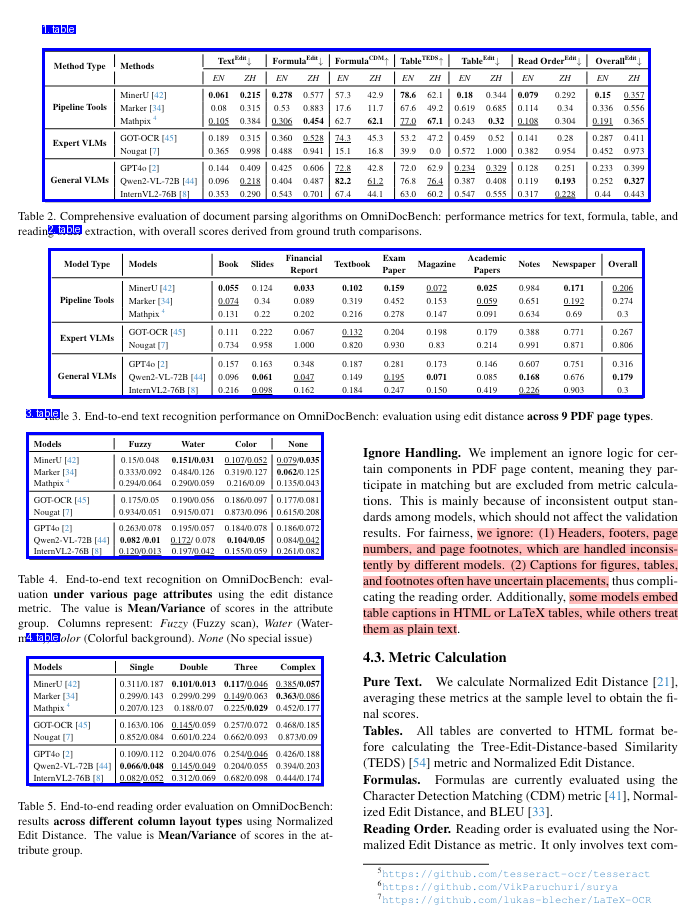

In [72]:
bbox_data = parse_bbox_from_response(response_thinking)
print(f"共解析到 {len(bbox_data)} 个版面元素")

if bbox_data:
    vis_img = draw_bboxes_on_image(INPUT_IMAGE_PATH, bbox_data)
    display(vis_img)
else:
    print("未解析到 bbox 信息")